In [ ]:
import pandas as pd

df = pd.read_csv('charlottesville_precip_cleaned.csv')
df.head()

# Drop empty columns
cols_to_drop = ['Snow', 'Average Temperature']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# Drop rows with missing precipitation or max/min temperature data
required_cols = ['PRCP (Inches)', 'TMAX (Degrees Fahrenheit)', 'TMIN (Degrees Fahrenheit)']
df = df.dropna(subset=[col for col in required_cols if col in df.columns])

df['Date'] = pd.to_datetime(df['Date'])

# Keep only data from 2007 through 2026
df = df[(df['Date'].dt.year >= 2007) & (df['Date'].dt.year <= 2026)]

df['YearMonth'] = df['Date'].dt.to_period('M')

# Aggregate daily precipitation into monthly totals
monthly_precip = (
    df.groupby('YearMonth')['PRCP (Inches)']
    .sum()
    .reset_index()
)

# Convert YearMonth back to timestamp for modeling
monthly_precip['YearMonth'] = monthly_precip['YearMonth'].dt.to_timestamp()

monthly_precip = monthly_precip.rename(columns={'PRCP (Inches)': 'Monthly_PRCP_Total'})

# Show cleaned daily data
print("Cleaned daily dataset:")
print(df.head())

print("\nMonthly aggregated precipitation dataset:")
print(monthly_precip.head())

print("\nShape of monthly dataset:", monthly_precip.shape)

Cleaned daily dataset:
        Date  TMAX (Degrees Fahrenheit)  TMIN (Degrees Fahrenheit)  \
0 2007-03-30                       65.0                       44.0   
1 2007-03-31                       64.0                       47.0   
2 2007-04-01                       62.0                       46.0   
3 2007-04-02                       78.0                       55.0   
4 2007-04-03                       81.0                       61.0   

   PRCP (Inches) YearMonth  
0           0.00   2007-03  
1           0.00   2007-03  
2           0.02   2007-04  
3           0.00   2007-04  
4           0.07   2007-04  

Monthly aggregated precipitation dataset:
   YearMonth  Monthly_PRCP_Total
0 2007-03-01                0.00
1 2007-04-01                4.01
2 2007-05-01                2.31
3 2007-06-01                5.06
4 2007-07-01                1.72

Shape of monthly dataset: (228, 2)


step 2: modeling methodology

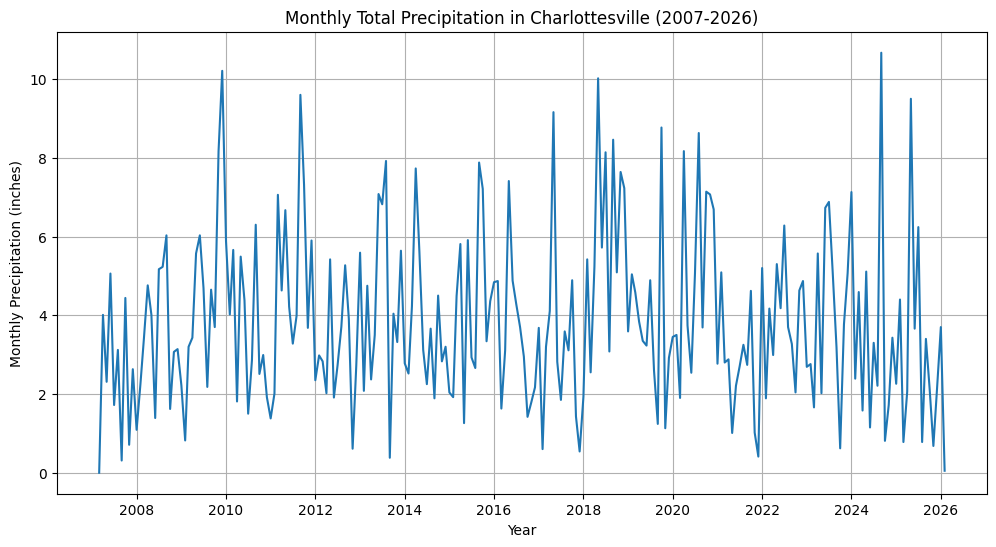

In [ ]:
#visualize full monthly time series

import matplotlib.pyplot as plt

#plot full monthly precipitation time series
plt.figure(figsize=(12,6))
plt.plot(monthly_precip['YearMonth'],
         monthly_precip['Monthly_PRCP_Total'])
plt.title("Monthly Total Precipitation in Charlottesville (2007-2026)")
plt.xlabel("Year")
plt.ylabel("Monthly Precipitation (inches)")
plt.grid(True)
plt.show()

In [ ]:
#linear regression to assess long-term trend

import numpy as np
import statsmodels.api as sm

#create numeric time index
monthly_precip['Time_Index'] = np.arange(len(monthly_precip))

#define dependent and independent variables
X = monthly_precip['Time_Index']
y = monthly_precip['Monthly_PRCP_Total']

#add constant for intercept
X = sm.add_constant(X)

#fit linear regression model
trend_model = sm.OLS(y, X).fit()

#print regression summary
print(trend_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Monthly_PRCP_Total   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.01136
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.915
Time:                        18:23:51   Log-Likelihood:                -500.18
No. Observations:                 228   AIC:                             1004.
Df Residuals:                     226   BIC:                             1011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8896      0.288     13.516      0.0

In [ ]:
#train-test split (chronological)

#split into training (2007-2023) and testing (2024-2026)
train = monthly_precip[monthly_precip['YearMonth'].dt.year <= 2023]
test = monthly_precip[monthly_precip['YearMonth'].dt.year >= 2024]

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (202, 3)
Testing shape: (26, 3)


In [ ]:
#fit SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

#fit SARIMA model on training data
sarima_model = SARIMAX(train['Monthly_PRCP_Total'],
                       order=(0,0,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit()

#print model summary
print(sarima_results.summary())

In [ ]:
#forecast on test set

#forecast for length of test set
forecast = sarima_results.forecast(steps=len(test))

#add forecast to test dataframe
test = test.copy()
test.loc[:, 'Forecast'] = forecast.values

In [ ]:
#plot forecast vs actual

plt.figure(figsize=(12,6))

#plot training data
plt.plot(train['YearMonth'],
         train['Monthly_PRCP_Total'],
         label='Training Data')

#plot actual test data
plt.plot(test['YearMonth'],
         test['Monthly_PRCP_Total'],
         label='Actual Test Data')

#plot forecast
plt.plot(test['YearMonth'],
         test['Forecast'],
         label='SARIMA Forecast')

plt.title("SARIMA Forecast vs Actual Monthly Precipitation")
plt.xlabel("Year")
plt.ylabel("Monthly Precipitation (Inches)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#calculate RMSE

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(
    test['Monthly_PRCP_Total'],
    test['Forecast']
))

print("Test RMSE:", rmse)

In [ ]:
#seasonal naive forecast

import numpy as np
from sklearn.metrics import mean_squared_error

test = test.copy()

#create seasonal naïve forecast using last 12 months of training data
last_12_months = train['Monthly_PRCP_Total'][-12:].values

#repeat those values to match test length
seasonal_naive_forecast = np.tile(last_12_months,
                                  int(np.ceil(len(test)/12)))[:len(test)]

test.loc[:, 'Seasonal_Naive'] = seasonal_naive_forecast

#compute RMSE
rmse_naive = np.sqrt(mean_squared_error(
    test['Monthly_PRCP_Total'],
    test['Seasonal_Naive']
))

print("Seasonal Naïve RMSE:", rmse_naive)
print("SARIMA RMSE:", 2.559625287036727)

Step 3: Model Evaluation and Success Criteria

In [ ]:
# SARIMA RMSE is 2.56 inches, which does not reach our goal of 1.5 inches, but is still significantly better than the naive RMSE (3.39 inches)
print("AIC:", sarima_results.aic)

# This model ((0,0,1), (1,1,1,12)), has also has the lowest AIC (793.013), meaning best balance of fit and simplicity
models = [
    ((0,0,1), (1,1,1,12)),
    ((1,0,1), (1,1,1,12)),
    ((0,1,1), (1,1,1,12)),
    ((1,1,1), (1,1,1,12))
]

for order, seasonal in models:
    model = SARIMAX(train['Monthly_PRCP_Total'],
                    order=order,
                    seasonal_order=seasonal,
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    results = model.fit(disp=False)
    print(f"Order: {order}, Seasonal: {seasonal}, AIC: {results.aic}")

# The parameters with statistical significance at alpha=0.05 are ma.S.L12 and sigma2
# ma.L1 insignificance shows that last period (t-1, last month) shock doesn't explain current period (t, this month) preciptitation
# ar.S.L12 being borderline significant shows that overall precicipitation may be slightly affected by the value from 12 months ago
# ma.S.L12 being very significant shows that shocks from 12 months ago are very influential (seasonal shock correlation)
# sigma2 being significant confirms variance is nonzero

# INTERPRETATION:
# Month-to-month differences are not very important
# Seasonal persistence (same month last year) is moderately important
# Seasonal shocks are very important
p_values = sarima_results.pvalues

print("All p-values:\n", p_values)

significant = p_values[p_values < 0.05]
not_significant = p_values[p_values >= 0.05]

print("\nSignificant parameters:\n", significant)
print("\nNot significant parameters:\n", not_significant)

In [ ]:
# Checking residual values

# Ljung-Box p-values are >0.05 (no autocorrelation)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print(lb_test)

# The residuals table has no trends (residuals are random)
# Residual histogram is normal (residuals are normally distributed)
# QQ-plot is mostly random (except at very edges), so approximately normal
# Correlogram shows no spikes beyond blue shaded area (except at zero as expected)
sarima_results.plot_diagnostics(figsize=(10, 8))
plt.show()

# We can conclude that our SARIMA MODEL ((0,0,1)(1,1,1,12)) is statistically valid and well specified, even if RMSE is not what we'd hoped.